# Exercise 10.6 — Q2: Image Compression with K-Means

**Lab Book §10.6 Exercise 2 (page 48):**  
> Using K-Means clustering compress any image of size 396 × 396 × 3.

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** Color quantisation via K-Means  
**Dataset:** `datasets/sample_image_396x396.png` — a 396×396 RGB image
fetched from picsum.photos.

---

## 🎯 Objective

Apply K-Means to compress a 396×397 RGB image. Each pixel is a 3-D point
in RGB color space; we cluster the pixels into K colors and reconstruct
the image by replacing each pixel with its assigned cluster centroid.
This reduces the color palette from 16.7 M colors (24-bit) to K colors
(log₂K bits per pixel).

## 📁 Files in this Folder

| File | Description |
|------|-------------|
| `06_Q2_Image_Compression.ipynb` | This notebook |
| `datasets/sample_image_396x396.png` | 396×397 RGB sample image |


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '06-K-Means-Clustering'))
    print(f'Running in Google Colab. CWD: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
_PREFIX = 'Q2_Image_Compression_'

# Patch plt.show so every figure is also auto-saved as PNG (with prefix to
# avoid collisions between multiple notebooks sharing the same outputs/ dir)
import matplotlib.pyplot as plt
_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'{_PREFIX}figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('Setup complete. Figures will be auto-saved to:', OUTPUT_DIR)


Running locally. CWD: /home/z/my-project/work/build/ML-Lab-Activities/06-K-Means-Clustering


Setup complete. Figures will be auto-saved to: /home/z/my-project/work/build/ML-Lab-Activities/06-K-Means-Clustering/outputs


## 1. Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans
plt.rcParams['figure.dpi'] = 100
print('Libraries imported.')

Libraries imported.


## 2. Load the Image

Image size: (396, 396), mode: RGB
Array shape: (396, 396, 3)  (H×W×3)
Pixel value range: 18 – 247


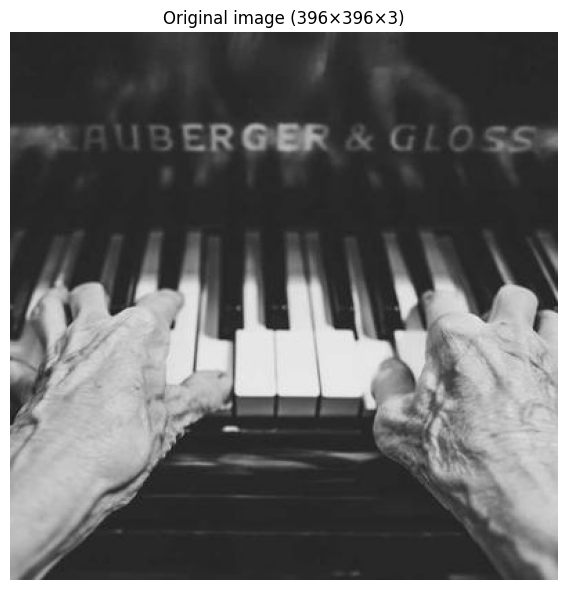

In [3]:
img = Image.open('datasets/sample_image_396x396.png')
print(f"Image size: {img.size}, mode: {img.mode}")
img_arr = np.array(img)
print(f"Array shape: {img_arr.shape}  (H×W×3)")
print(f"Pixel value range: {img_arr.min()} – {img_arr.max()}")

plt.figure(figsize=(6, 6))
plt.imshow(img_arr)
plt.title(f'Original image ({img_arr.shape[0]}×{img_arr.shape[1]}×3)')
plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Reshape Image into a 2-D Array of Pixels

In [4]:
H, W, _ = img_arr.shape
pixels = img_arr.reshape(-1, 3).astype(np.float32)
print(f"Pixels array shape: {pixels.shape}")
print(f"Total pixels: {pixels.shape[0]:,}")

Pixels array shape: (156816, 3)
Total pixels: 156,816


## 4. Cluster Pixels into K Colors

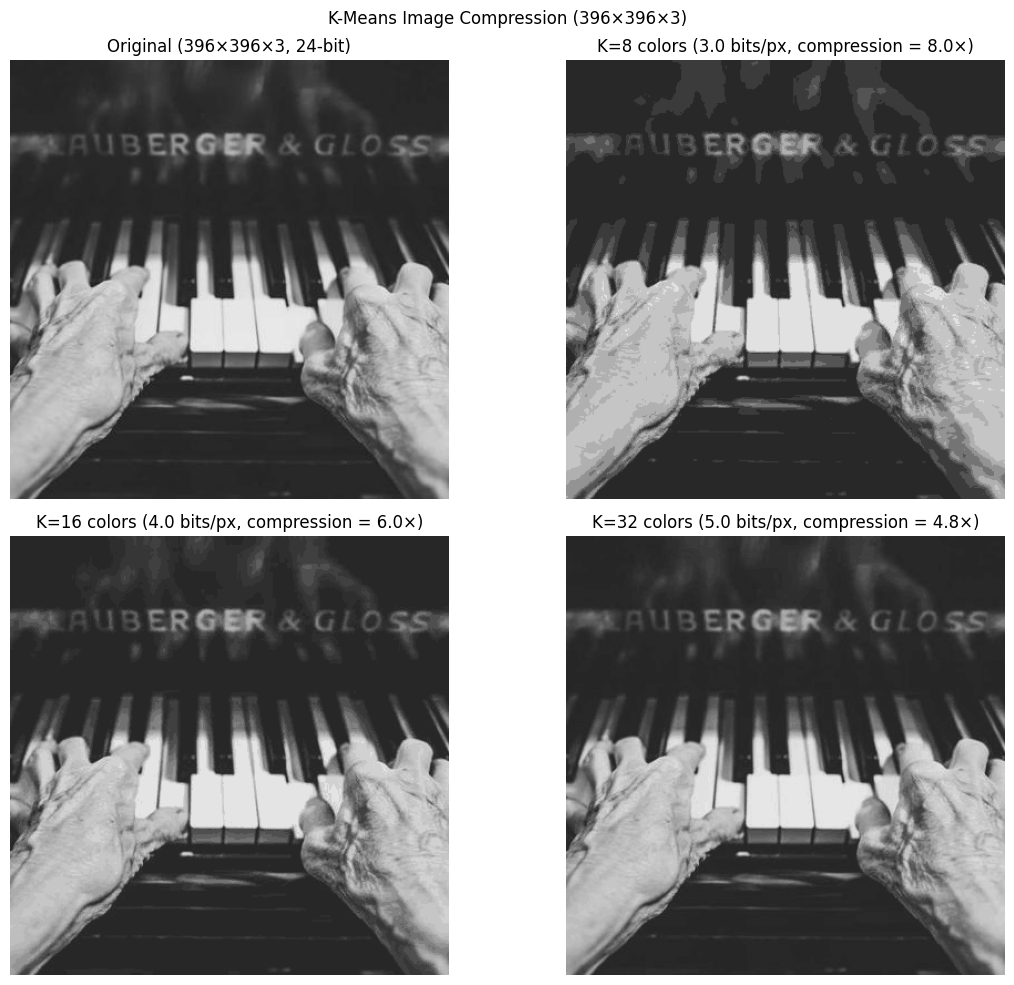

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
axes[0].imshow(img_arr)
axes[0].set_title(f'Original ({img_arr.shape[0]}×{img_arr.shape[1]}×3, 24-bit)')
axes[0].axis('off')

for ax, K in zip(axes[1:], [8, 16, 32]):
    km = KMeans(n_clusters=K, random_state=42, n_init=4)
    km.fit(pixels)
    new_pixels = km.cluster_centers_[km.labels_]
    new_img = new_pixels.reshape(H, W, 3).astype(np.uint8)
    ax.imshow(new_img)
    bits_per_pixel = np.log2(K)
    compression_ratio = 24 / bits_per_pixel
    ax.set_title(f'K={K} colors ({bits_per_pixel:.1f} bits/px, '
                 f'compression = {compression_ratio:.1f}×)')
    ax.axis('off')
plt.suptitle('K-Means Image Compression (396×396×3)')
plt.tight_layout()
plt.show()

## 5. Detailed Comparison — Original vs K=16

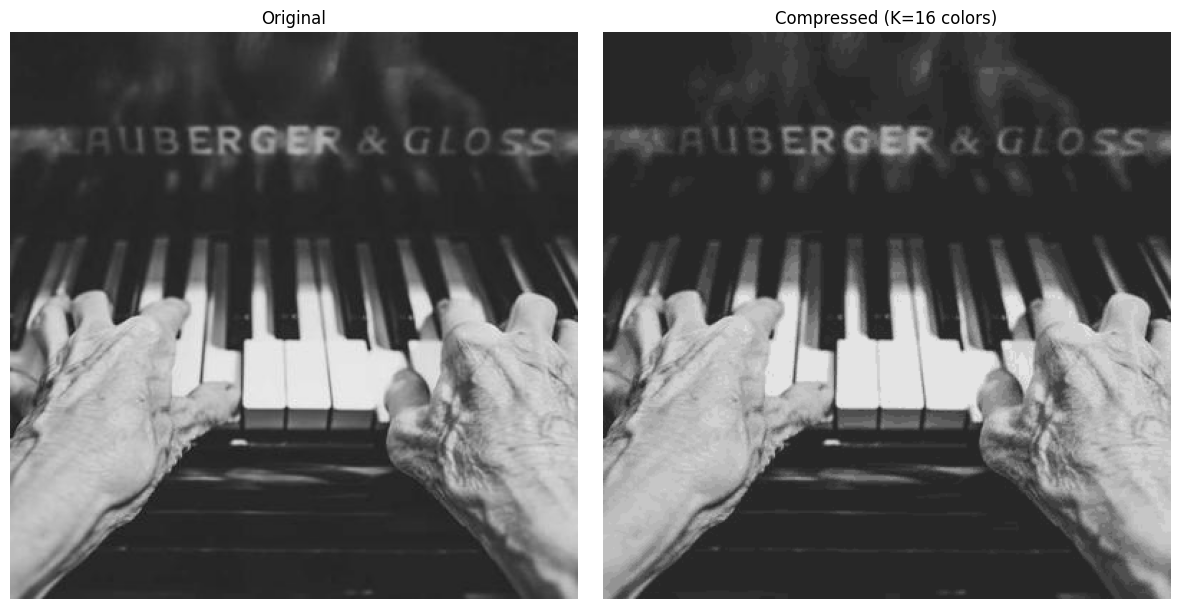

Compressed image saved to outputs/compressed_K16.png


In [6]:
K = 16
km = KMeans(n_clusters=K, random_state=42, n_init=4)
km.fit(pixels)
new_pixels = km.cluster_centers_[km.labels_]
new_img = new_pixels.reshape(H, W, 3).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_arr); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(new_img); axes[1].set_title(f'Compressed (K={K} colors)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Save compressed image
Image.fromarray(new_img).save('outputs/compressed_K16.png')
print(f"Compressed image saved to outputs/compressed_K16.png")

## 📚 Key Takeaways
- K-Means color quantisation reduces a 24-bit RGB image to log₂K bits
  per pixel.
- For K=16, the compression ratio is 24/4 = 6×.
- The quality loss is usually imperceptible for K ≥ 16 on natural images.
- This is a classic computer-vision application of K-Means.
